In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv(r'C:\Users\MKcomputer\Documents\Netflix_Movies_and_TV_Shows\netflix_titles.csv')

In [4]:
df.shape

(8807, 12)

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [9]:
df['director']= df['director'].fillna('Unknown')
df['cast']= df['cast'].fillna('Unknown')
df['country']= df['country'].fillna('Unknown')
df['date_added']= df['date_added'].fillna('Unknown')

In [10]:
df.dropna(subset=['rating', 'duration'], inplace= True)

In [11]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [12]:
df.shape[0]

8800

In [13]:
type_counts= df['type'].value_counts()
type_counts

type
Movie      6126
TV Show    2674
Name: count, dtype: int64

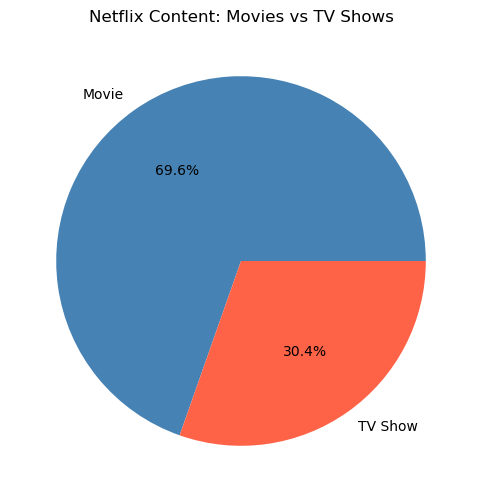

In [14]:
plt.figure(figsize=(8,6))
plt.pie(type_counts, labels= type_counts.index, autopct='%1.1f%%', colors=['steelblue', 'tomato'])
plt.title('Netflix Content: Movies vs TV Shows')
plt.show()

In [17]:
df.to_csv('netflix_clean.csv', index= False, sep='|')

In [18]:
df.shape

(8800, 12)

In [15]:
df.iloc[782][['title', 'director', 'release_year']]

title                 Bliss
director        Lance Young
release_year           1997
Name: 782, dtype: object

In [16]:
df.iloc[3125][['title', 'director', 'release_year']]

title           The Danish Girl
director             Tom Hooper
release_year               2015
Name: 3125, dtype: object

In [21]:
df.to_csv('netflix_clean.csv', index= False, sep='\t', encoding='utf-8-sig')

In [18]:
df.iloc[8196]

show_id                                                     s8204
type                                                        Movie
title                                         The Bare-Footed Kid
director                                               Johnnie To
cast            Aaron Kwok, Lung Ti, Maggie Cheung, Chien-lien...
country                                                 Hong Kong
date_added                                        August 16, 2018
release_year                                                 1993
rating                                                      TV-14
duration                                                   83 min
listed_in                Action & Adventure, International Movies
description     While working at a family friend's business, a...
Name: 8203, dtype: object

In [19]:
df.iloc[3125]['director']

'Tom Hooper'

In [22]:
print(repr(df.iloc[3125].to_dict()))

{'show_id': 's3126', 'type': 'Movie', 'title': 'The Danish Girl', 'director': 'Tom Hooper', 'cast': 'Eddie Redmayne, Alicia Vikander, Ben Whishaw, Sebastian Koch, Amber Heard, Matthias Schoenaerts, Pip Torrens, Nicholas Woodeson, Emerald Fennell, Adrian Schiller', 'country': 'United Kingdom, United States, Germany, Denmark, Belgium, Japan', 'date_added': 'December 16, 2019', 'release_year': 2015, 'rating': 'R', 'duration': '120 min', 'listed_in': 'Dramas, Independent Movies, International Movies', 'description': 'In 1920s Denmark, married artists embark on a journey of unconditional love when the husband announces his intentions to live life as a woman.'}


In [23]:
df.to_csv('netflix_clean.csv', index= False, sep='\t', encoding='utf-8-sig', quoting=1)

In [24]:
!pip install pyodbc sqlalchemy

In [25]:
from sqlalchemy import create_engine

engine = create_engine('mssql+pyodbc://DESKTOP-7FFU3P1\\SQLEXPRESS/NetflixDB?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes')

df.to_sql('Netflix', engine, if_exists='replace', index=False)


100

In [26]:
df= df[df['country'] !='Unknown']

In [27]:
df.to_sql('Netflix', engine, if_exists='replace', index=False)

140

In [28]:
print(df.shape)

(7970, 12)
